In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [11]:
#Configuration
sequence_length = 10  # Define your sequence length
input_features = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Tilt_X', 'Tilt_Y', 'Tilt_Z', 'Mag_X', 'Mag_Y', 'Mag_Z', 'Head', 'Temp', 'Press', 'delta_Alt']
#input_features = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Tilt_X', 'Tilt_Y', 'Tilt_Z', 'Head']
target_features = ['delta_Lat', 'delta_Lng']

train_folder = 'data/train'
test_folder = 'data/test'

In [12]:
# Load and preprocess data from all CSV files in the 'train' folder
def load_data_from_folder(folder_path):
    sequences = []
    targets = []
    
    for file in os.listdir(folder_path):
        if file.endswith('.csv'):
            # Load the CSV file
            file_path = os.path.join(folder_path, file)
            data = pd.read_csv(file_path, delimiter=";")
            
            if len(data) < sequence_length:
                # Skip files with fewer rows than the sequence length
                continue
            
            # Normalize the input data (sensor data)
            input_data = data[input_features].values
            
            # Target data (deltas)
            target_data = data[target_features].values * 1000
            
            # Create sequences of input data and corresponding target deltas
            for i in range(len(data) - sequence_length):
                sequences.append(input_data[i:i + sequence_length])
                targets.append(target_data[i + sequence_length])

    return np.array(sequences), np.array(targets)

In [13]:
# Load data
X_train, y_train = load_data_from_folder(train_folder)
X_test, y_test = load_data_from_folder(test_folder)

In [14]:
# Define the LSTM model
model = Sequential()
# Add Dense encoding layer before LSTM (encoding input features into a smaller space)
model.add(Dense(16, activation='leaky_relu', input_shape=(sequence_length, len(input_features))))
model.add(Dense(32, activation='leaky_relu'))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(32, activation='leaky_relu'))
model.add(Dense(16, activation='leaky_relu'))
model.add(Dense(2))

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=300, batch_size=32)

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")

# Save the trained model
model.save('lstm_delta_gps_model.keras')

Epoch 1/300


c:\Users\Usuario\anaconda3\envs\Quanvia\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0117 - val_loss: 0.0059
Epoch 2/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0078 - val_loss: 0.0058
Epoch 3/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0071 - val_loss: 0.0038
Epoch 4/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0059 - val_loss: 0.0033
Epoch 5/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0057 - val_loss: 0.0034
Epoch 6/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0044 - val_loss: 0.0036
Epoch 7/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 - val_loss: 0.0034
Epoch 8/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0044 - val_loss: 0.0036
Epoch 9/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0042 - val_loss: 0.0033
Epoch 10/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0042 - val_loss: 0.0030
Epoch 11/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039 - val_loss: 0.0041
Epoch 12/300
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - val_lo

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


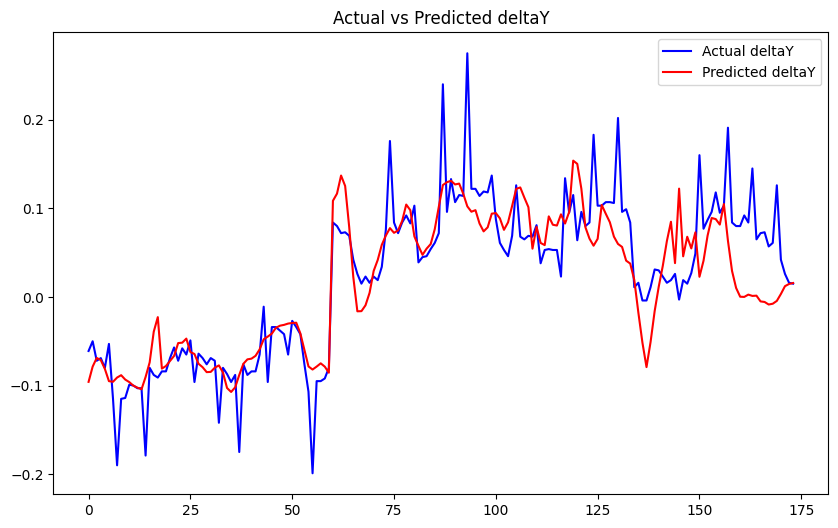

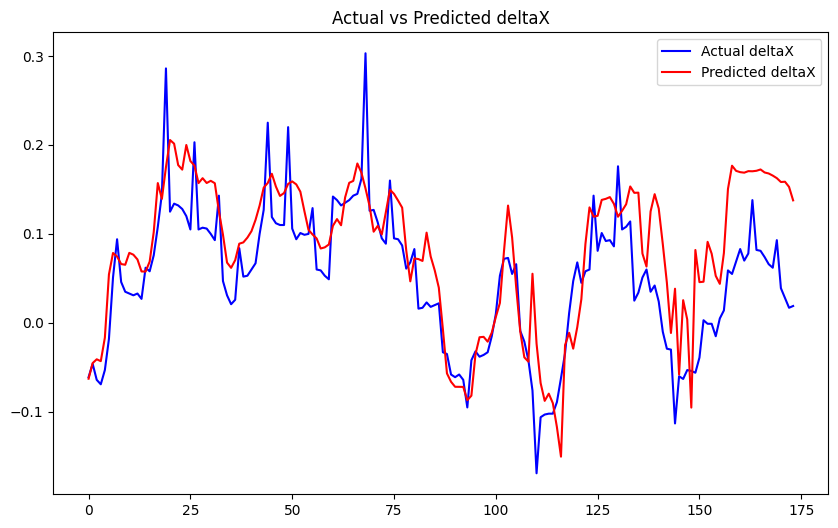

In [15]:

# Make predictions using the model on the test set
y_pred = model.predict(X_test)

# Plot actual vs predicted for deltaY
plt.figure(figsize=(10, 6))
plt.plot(y_test[:, 0], label='Actual deltaY', color='blue')
plt.plot(y_pred[:, 0], label='Predicted deltaY', color='red')
plt.title('Actual vs Predicted deltaY')
plt.legend()
plt.show()

# Plot actual vs predicted for deltaX
plt.figure(figsize=(10, 6))
plt.plot(y_test[:, 1], label='Actual deltaX', color='blue')
plt.plot(y_pred[:, 1], label='Predicted deltaX', color='red')
plt.title('Actual vs Predicted deltaX')
plt.legend()
plt.show()


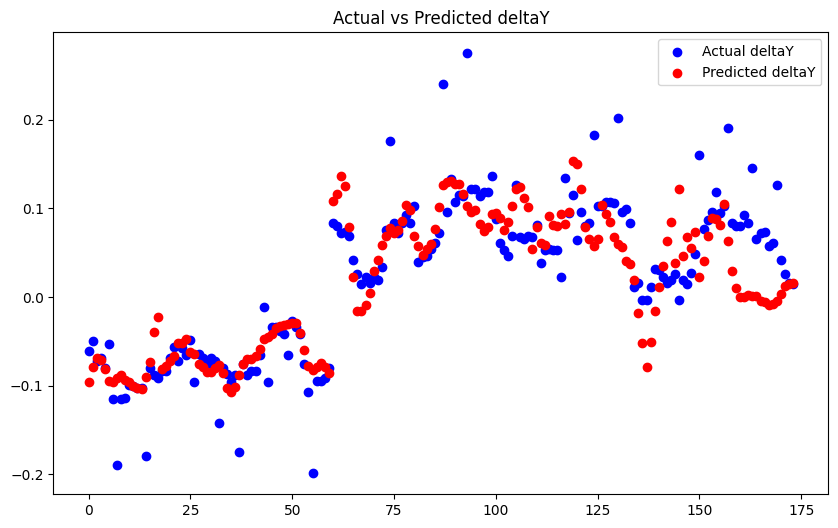

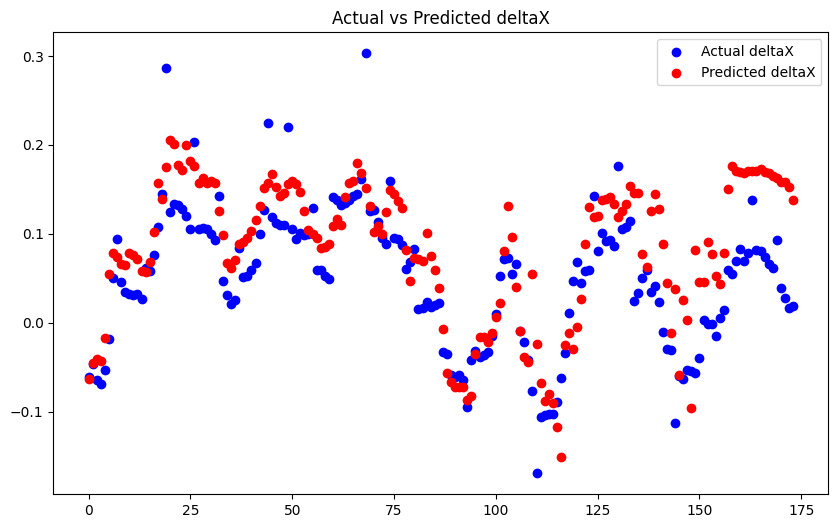

In [16]:
# Plot actual vs predicted for deltaY as scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test[:, 0])), y_test[:, 0], label='Actual deltaY', color='blue')
plt.scatter(range(len(y_pred[:, 0])), y_pred[:, 0], label='Predicted deltaY', color='red')
plt.title('Actual vs Predicted deltaY')
plt.legend()
plt.show()

# Plot actual vs predicted for deltaX as scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test[:, 1])), y_test[:, 1], label='Actual deltaX', color='blue')
plt.scatter(range(len(y_pred[:, 1])), y_pred[:, 1], label='Predicted deltaX', color='red')
plt.title('Actual vs Predicted deltaX')
plt.legend()
plt.show()

In [17]:
# Function to calculate real and predicted routes
def calculate_routes(file_path, sequence_length, input_features, model):
    data = pd.read_csv(file_path, delimiter=";")
    
    # Get the first point from 'Lat' and 'Lng'
    lat_real = [data.iloc[0]['Lat']]
    lng_real = [data.iloc[0]['Lng']]
    
    # Initialize real route
    for i in range(1, len(data)):
        # Get the deltas
        delta_lat = data.iloc[i]['delta_Lat']
        delta_lng = data.iloc[i]['delta_Lng']
        
        # Calculate next point based on the previous one
        lat_real.append(lat_real[-1] + delta_lat)
        lng_real.append(lng_real[-1] + delta_lng)
    
    # Now calculate the predicted route
    lat_pred = [data.iloc[0]['Lat']]
    lng_pred = [data.iloc[0]['Lng']]
    
    # Extract input data
    input_data = data[input_features].values
    
    # Predict deltas and accumulate to form the predicted route
    for i in range(1, len(data)):
        # Prepare sequence for prediction
        if i >= sequence_length:
            X_test = input_data[i-sequence_length:i].reshape(1, sequence_length, len(input_features))
            delta_lat_pred, delta_lng_pred = model.predict(X_test)[0] / 1000

            lat_pred.append(lat_pred[-1] + delta_lat_pred)
            lng_pred.append(lng_pred[-1] + delta_lng_pred)

        else:
            # For first few rows, just use the real data
            #X_test = np.pad(input_data[:i], ((sequence_length-i, 0), (0, 0)), mode='constant').reshape(1, sequence_length, len(input_features))

            lat_pred.append(lat_real[i])
            lng_pred.append(lng_real[i])

        # Predict deltas
        #delta_lat_pred, delta_lng_pred = model.predict(X_test)[0] / 1000
        
        # Calculate next predicted point
        #lat_pred.append(lat_pred[-1] + delta_lat_pred)
        #lng_pred.append(lng_pred[-1] + delta_lng_pred)
    
    return lat_real, lng_real, lat_pred, lng_pred

# Function to plot real and predicted routes for each test file
def plot_routes(test_folder, sequence_length, input_features, model):
    test_files = [f for f in os.listdir(test_folder) if f.endswith('.csv')]
    num_files = len(test_files)
    
    fig, axes = plt.subplots(nrows=num_files, ncols=1, figsize=(8, num_files * 6))
    
    if num_files == 1:
        axes = [axes]  #Ensure axes is iterable if there's only one file
    
    for idx, test_file in enumerate(test_files):
        file_path = os.path.join(test_folder, test_file)
        
        lat_real, lng_real, lat_pred, lng_pred = calculate_routes(file_path, sequence_length, input_features, model)
        
        # Plot real and predicted points
        axes[idx].plot(lng_real, lat_real, color='blue', label='Real Route', marker='o', markersize=5)
        axes[idx].plot(lng_pred, lat_pred, color='red', label='Predicted Route', marker='o', markersize=5)
        
        axes[idx].set_title(f'Test File: {test_file}')
        axes[idx].set_xlabel('Lng')
        axes[idx].set_ylabel('Lat')
        axes[idx].legend()
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms

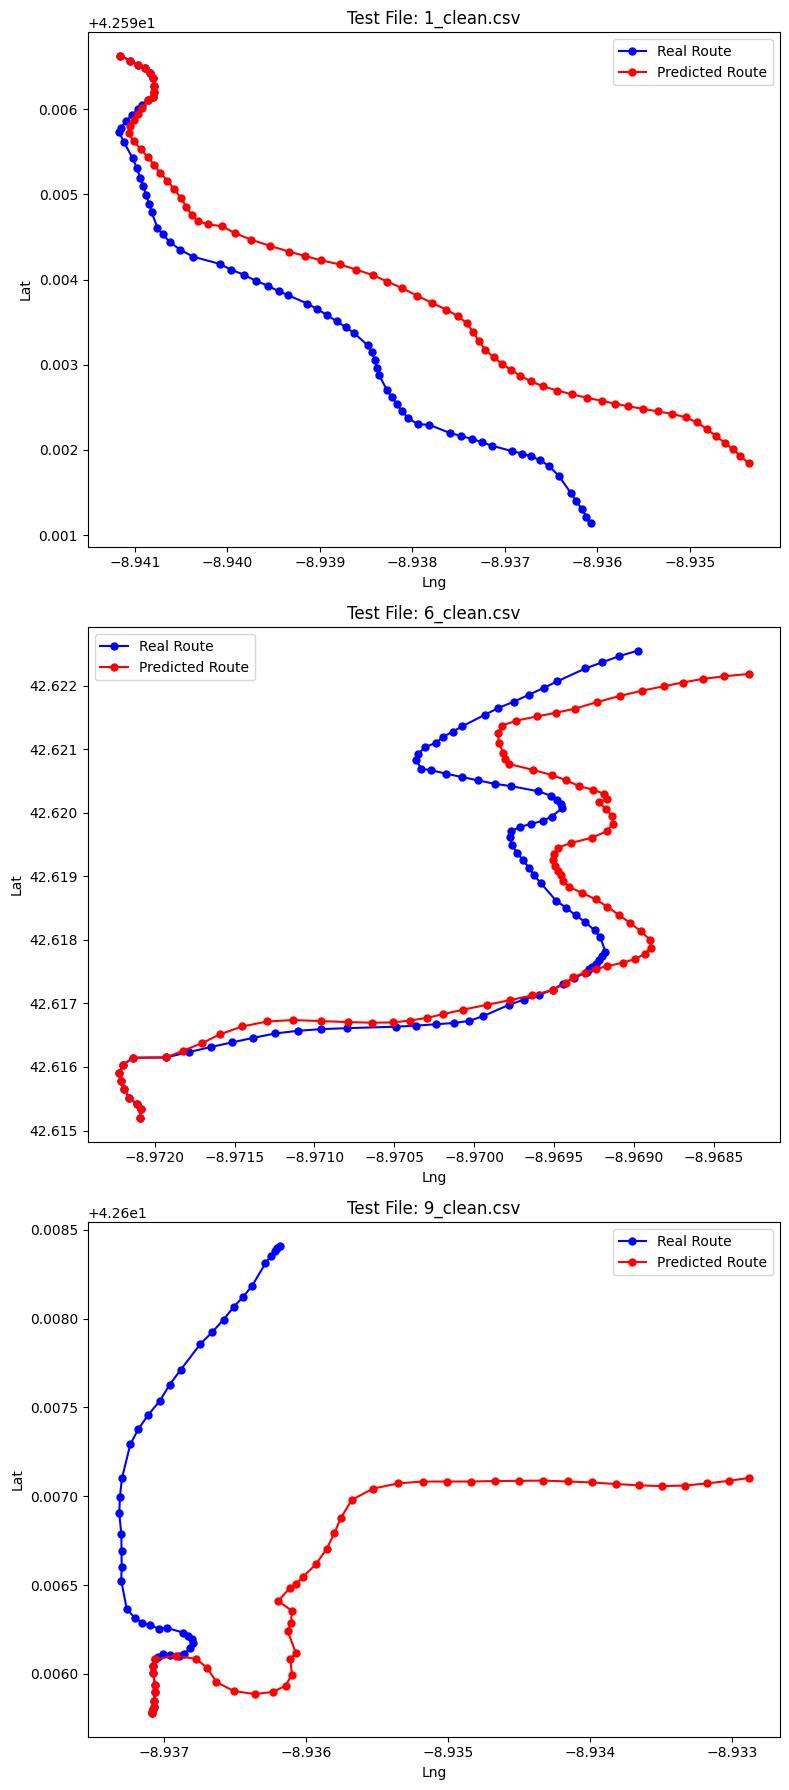

In [18]:
sequence_length = 10
plot_routes(test_folder, sequence_length, input_features, model)